In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
print(fuzz.__version__)

0.5.0


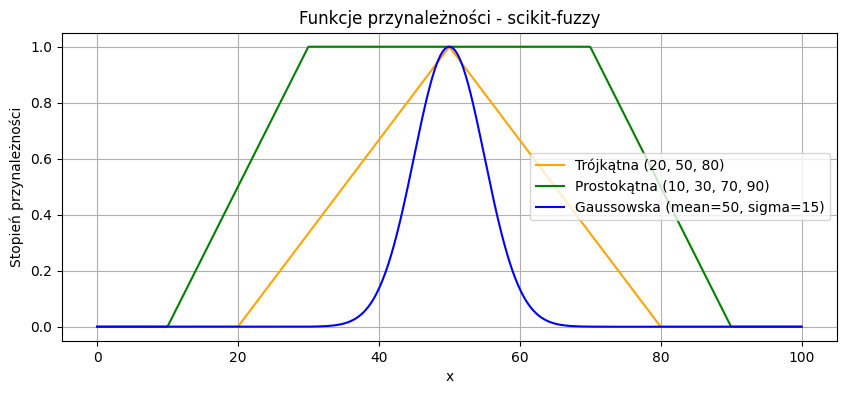

In [6]:
# uniwersum
x = np.linspace(0, 100, 1000)

# funkcje przynależności
trimf = fuzz.trimf(x, [20, 50, 80])
trapmf = fuzz.trapmf(x, [10, 30, 70, 90])
gaussmf = fuzz.gaussmf(x, mean=50, sigma=5)
# mean - średnia
# sigma - szerokosc funkcji


plt.figure(figsize=(10, 4))

plt.plot(x, trimf, label="Trójkątna (20, 50, 80)", color='orange')
plt.plot(x, trapmf, label="Prostokątna (10, 30, 70, 90)", color='green')
plt.plot(x, gaussmf, label="Gaussowska (mean=50, sigma=15)", color='blue')


plt.title("Funkcje przynależności - scikit-fuzzy")
plt.xlabel('x')
plt.ylabel("Stopień przynależności")
plt.grid(True)
plt.legend()
plt.show()

```
Przypomnienie - założenia zadania:
Wejściowe zmienne rozmyte:
  ● Życie gracza (niskie, średnie, wysokie)
  ● Odległość w blokach (mała, duża)


Wyjściowe zmienne rozmyte:
  ● Atak (brak, ostrożny, zdecydowany)  


Reguły aktywacji (Jakie określenia aktywują jaki poziom ataku):
  ● Reguła 1 (życie niskie → zdecydowany atak)
  ● Reguła 2 (życie średnie i odległość duża → średni atak)
  ● Reguła 3 (życie średnie i odległość mała → średni atak)
  ● Reguła 4 (życie wysokie i odległość mała → brak ataku)


Życie gracza
  ● Niskie (funkcja trójkątna [0,0,40])
  ● Średnie (funkcja trójkątna [30,50,70])
  ● Wysokie(funkcja trójkątna [60,100,100])


Odległość
  ● Blisko (funkcja trójkątna [0,0,15])
  ● Daleko (funkcja trójkątna [10,50,50])


Poziom ataku:
  ● Brak ataku (funkcja trójkątna [0,0,30])
  ● Ostrożny atak  (funkcja trójkątna [50,70,90])
  ● Zdecydowany atak  (funkcja trójkątna [80,100,100])
```

Poziom ataku: 68.47


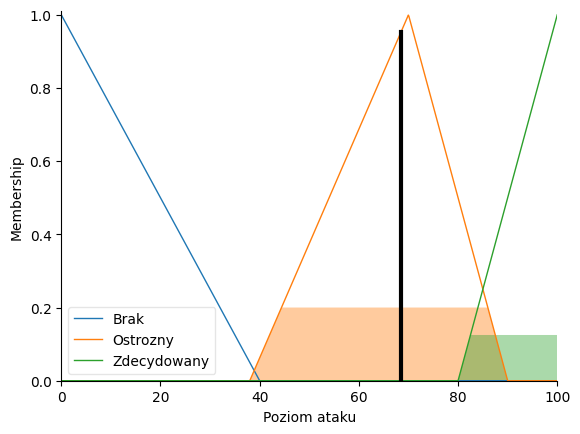

In [14]:
from IPython.core.interactiveshell import dis
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Dane wejściowe
life = ctrl.Antecedent(np.linspace(0, 100, 1000), "Zycie gracza")
distance = ctrl.Antecedent(np.linspace(0, 50, 1000), "Odleglosc")

# - dane wyjściowe
attack = ctrl.Consequent(np.linspace(0, 100, 1000), 'Poziom ataku')


# 2. Funkcje przynaleznosci
life['Niskie'] = fuzz.trimf(life.universe, [0, 0, 40])
life["Srednie"] = fuzz.trimf(life.universe, [30, 50, 70])
life["Wysokie"] = fuzz.trimf(life.universe, [60, 100, 100])

distance["Mala"] = fuzz.trimf(distance.universe, [0, 0, 15])
distance["Duza"] = fuzz.trimf(distance.universe, [10, 50, 50])

attack["Brak"] = fuzz.trimf(attack.universe, [0, 0, 40])
attack["Ostrozny"] = fuzz.trimf(attack.universe, [38, 70, 90])
attack["Zdecydowany"] = fuzz.trimf(attack.universe, [80, 100, 100])


# 3. Reguły
rule1 = ctrl.Rule(life["Niskie"], attack["Zdecydowany"])
rule2 = ctrl.Rule(life["Srednie"] & distance["Duza"], attack["Ostrozny"])
rule3 = ctrl.Rule(life["Srednie"] & distance["Mala"], attack["Ostrozny"])
rule4 = ctrl.Rule(life["Wysokie"] & distance["Mala"], attack["Brak"])


# 4. Budowa systemu
attack_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])

attack_sim = ctrl.ControlSystemSimulation(attack_ctrl)



# 5. Symulacja
attack_sim.input['Zycie gracza'] = 35
attack_sim.input["Odleglosc"] = 12

attack_sim.compute()

print(f"Poziom ataku: {attack_sim.output['Poziom ataku']:.2f}")
attack.view(sim=attack_sim)

# **ZADANEI DOMOWE 1**
- 1. Wygeneruj wykresy funkcji trójkątnych ciepło(10,30,40) i gorąco(30,40,50).
- 2. Wygeneruj wykres przedstawiający sumę zbiorów ciepło i gorąco
- 3. Wygeneruj wykres przedstawiający iloczyn zbiorów ciepło i gorąco
- 4. Wygeneruj wykres przedstawiający negację zbioru ciepło


# **ZADANEI DOMOWE 2**
- dopracuj system Steve vs Szkielet do perfekcji według wąłsnego uznanania ;)